In [2]:
import numpy as np
import pandas as pd

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

#GIC (composite)

In [15]:
storm_clf      = joblib.load('icarus_flare_classifier.pkl')

print(f"Model loaded   : {type(storm_clf).__name__}")

Model loaded   : XGBClassifier


In [16]:
try:
    with open('feature_names.txt', 'r') as f:
        content = f.read()
        print(content)
except FileNotFoundError:
    print("Error: 'feature_names.txt' not found. Please ensure the file exists in the current directory.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

TOTUSJH
TOTBSQ
TOTPOT
TOTUSJZ
ABSNJZH
SAVNCPP
USFLUX
AREA_ACR
TOTFZ
MEANPOT
R_VALUE
EPSZ
SHRGT45
MEANSHR
MEANGAM
MEANGBT
MEANGBZ
MEANGBH
MEANJZH
TOTFY
MEANJZD
MEANALP
TOTFX
EPSY
EPSX



In [17]:
feature_names_list = []
with open('feature_names.txt', 'r') as f:
    for line in f:
        feature_names_list.append(line.strip())

print(f"Loaded {len(feature_names_list)} feature names: {feature_names_list[:5]}...")

Loaded 25 feature names: ['TOTUSJH', 'TOTBSQ', 'TOTPOT', 'TOTUSJZ', 'ABSNJZH']...


In [18]:
def _preprocess_sharp(sharp_input: dict) -> pd.DataFrame:

    MEANSHR_TRAIN_MEDIAN = 22.459   # median from sharp_solar_flares.csv

    row = pd.DataFrame([sharp_input])

    # Quality gate — skip if field absent
    if 'QUALITY' in row.columns and row['QUALITY'].iloc[0] > 65536:
        raise ValueError(
            f"QUALITY={row['QUALITY'].iloc[0]} exceeds threshold (65536). "
            "Record flagged as noisy — do not pass to model."
        )

    # Fill missing MEANSHR
    if 'MEANSHR' not in row.columns or pd.isna(row['MEANSHR'].iloc[0]):
        row['MEANSHR'] = MEANSHR_TRAIN_MEDIAN

    # Keep only the 25 features the model expects, in exact order
    return row[feature_names_list]


def predict_flare_probability(sharp_params: dict) -> float:

    X_row = _preprocess_sharp(sharp_params)
    prob  = storm_clf.predict_proba(X_row)[0, 1]
    return float(prob)

In [19]:
print("\n" + "=" * 60)
print("STAGE 2: Loading Kp / GIC Data")
print("=" * 60)

kp_df = pd.read_csv('/content/Kp_ap_since_1932.csv')
kp_df.rename(columns={"Kp_value": "Kp_raw"}, inplace=True)
kp_df["Kp"]  = kp_df["Kp_raw"] / 3          # encoded as thirds×3 → true 0–9 scale
kp_df["GIC"] = 0.7 * np.exp(0.6 * kp_df["Kp"])
kp_df["GIC"] += np.random.normal(0, 0.1 * kp_df["GIC"])

print(f"Kp range (corrected): {kp_df['Kp'].min():.1f} – {kp_df['Kp'].max():.1f}")


def gic_from_kp(kp: float) -> float:
    return 0.7 * np.exp(0.6 * kp)



STAGE 2: Loading Kp / GIC Data
Kp range (corrected): 0.5 – 7.5


In [20]:
FLARE_AMPLIFICATION = 2.0   # tune with real GIC measurements when available

def get_risk_tier(gic: float) -> str:
    if gic < 2:    return "LOW"
    elif gic < 10: return "MEDIUM"
    elif gic < 50: return "HIGH"
    else:          return "CRITICAL"


def composite_gic(kp: float, p_flare: float,
                  alpha: float = FLARE_AMPLIFICATION,
                  n_samples: int = 500) -> dict:
    """
    Composite GIC combining Kp model + teammate's flare probability.

    Formula: GIC = GIC_kp × (1 + α × P_flare) + multiplicative noise (10%)
    """
    det_gic   = gic_from_kp(kp)
    amplified = det_gic * (1 + alpha * p_flare)
    samples   = amplified + np.random.normal(0, 0.1 * amplified, n_samples)

    mean = float(np.mean(samples))
    low  = float(np.percentile(samples, 5))
    high = float(np.percentile(samples, 95))

    return {
        "kp":              kp,
        "p_flare":         round(p_flare, 3),
        "gic_kp_only":     round(det_gic, 2),
        "gic_composite":   round(mean, 2),
        "gic_low":         round(low,  2),
        "gic_high":        round(high, 2),
        "flare_boost_pct": round(alpha * p_flare * 100, 1),
        "risk":            get_risk_tier(mean),
    }

In [21]:
def generate_alert(result: dict) -> str:
    risk    = result["risk"]
    boost   = result["flare_boost_pct"]
    p_flare = result["p_flare"]

    flare_note = ""
    if p_flare > 0.6:
        flare_note = f"\n  ☀️  Active region flare probability: {p_flare*100:.0f}% (+{boost}% GIC amplification)"
    elif p_flare > 0.3:
        flare_note = f"\n  ☀️  Moderate flare probability: {p_flare*100:.0f}% (+{boost}% GIC boost)"

    return {
        "CRITICAL": "🚨 CRITICAL ALERT: Immediate grid protection action required!",
        "HIGH":     "⚠️  HIGH RISK: Prepare GIC mitigation measures.",
        "MEDIUM":   "⚡ Moderate geomagnetic disturbance expected.",
        "LOW":      "✅ Conditions normal. Continue monitoring.",
    }[risk] + flare_note

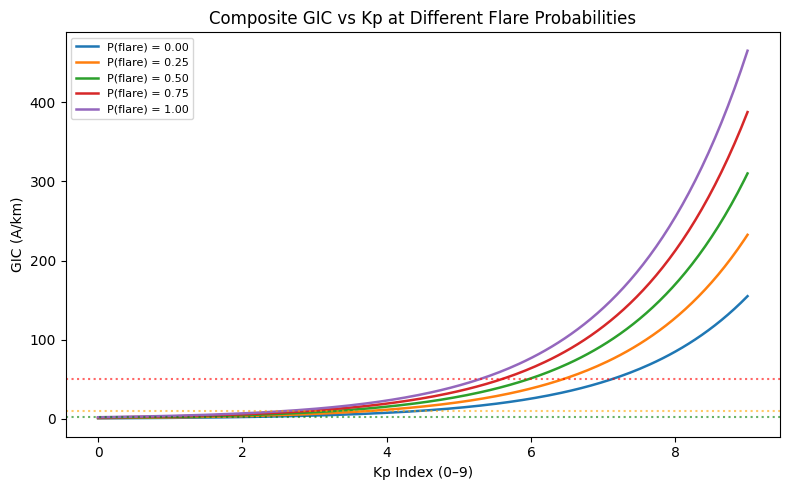

In [22]:
kp_values = np.linspace(0, 9, 200)
gic_kp    = 0.7 * np.exp(0.6 * kp_values)

# Plot 1: GIC vs Kp at different flare probabilities
plt.figure(figsize=(8, 5))
for p in [0.0, 0.25, 0.5, 0.75, 1.0]:
    plt.plot(kp_values, gic_kp * (1 + FLARE_AMPLIFICATION * p),
             label=f"P(flare) = {p:.2f}", linewidth=1.8)
plt.axhline(2,  linestyle=':', color='green',  alpha=0.6)
plt.axhline(10, linestyle=':', color='orange', alpha=0.6)
plt.axhline(50, linestyle=':', color='red',    alpha=0.6)
plt.xlabel("Kp Index (0–9)")
plt.ylabel("GIC (A/km)")
plt.title("Composite GIC vs Kp at Different Flare Probabilities")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


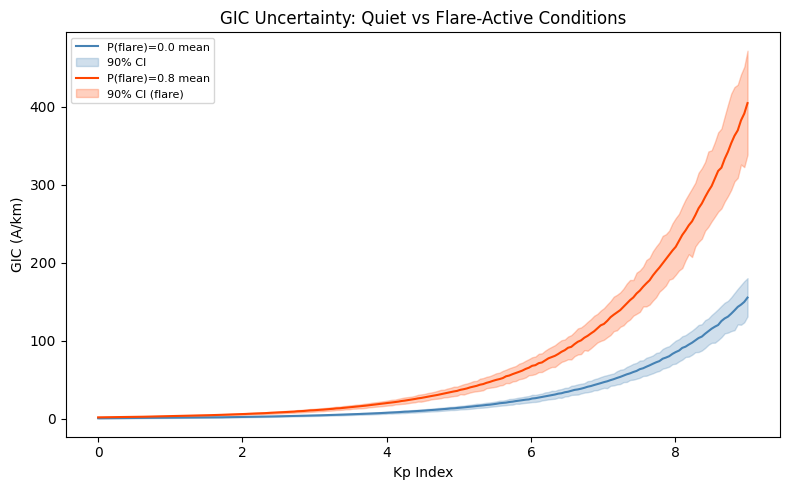

In [23]:
means_nf, lows_nf, highs_nf = [], [], []
means_fl, lows_fl, highs_fl = [], [], []
for kp in kp_values:
    r0 = composite_gic(kp, p_flare=0.0)
    r1 = composite_gic(kp, p_flare=0.8)
    means_nf.append(r0["gic_composite"]); lows_nf.append(r0["gic_low"]);  highs_nf.append(r0["gic_high"])
    means_fl.append(r1["gic_composite"]); lows_fl.append(r1["gic_low"]);  highs_fl.append(r1["gic_high"])

plt.figure(figsize=(8, 5))
plt.plot(kp_values, means_nf, color='steelblue',  label="P(flare)=0.0 mean")
plt.fill_between(kp_values, lows_nf, highs_nf, alpha=0.25, color='steelblue', label="90% CI")
plt.plot(kp_values, means_fl, color='orangered',  label="P(flare)=0.8 mean")
plt.fill_between(kp_values, lows_fl, highs_fl, alpha=0.25, color='orangered', label="90% CI (flare)")
plt.xlabel("Kp Index")
plt.ylabel("GIC (A/km)")
plt.title("GIC Uncertainty: Quiet vs Flare-Active Conditions")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [25]:
print("\n" + "=" * 60)
print("Active Region Forecast")
print("=" * 60)

flare_df   = pd.read_csv('/content/sharp_solar_flares.csv')
flare_df['MEANSHR'] = flare_df['MEANSHR'].fillna(flare_df['MEANSHR'].median())
sample_row = flare_df[flare_df['FlareNumber'] == 1].iloc[0]

sharp_input = {feat: sample_row[feat] for feat in feature_names_list}

p_flare = predict_flare_probability(sharp_input)
print(f"P(flare): {p_flare:.3f}")

current_kp = 6.5
result = composite_gic(kp=current_kp, p_flare=p_flare)

print(f"\n---- COMPOSITE GIC FORECAST ----")
print(f"  Kp (current):        {result['kp']}")
print(f"  P(flare):            {result['p_flare']}")
print(f"  GIC (Kp only):       {result['gic_kp_only']} A/km")
print(f"  GIC (composite):     {result['gic_composite']} A/km  (+{result['flare_boost_pct']}% flare boost)")
print(f"  90% CI:              [{result['gic_low']}, {result['gic_high']}]")
print(f"  Risk Tier:           {result['risk']}")
print(f"\n---- ALERT ----")
print(generate_alert(result))

print("\n" + "=" * 60)
print("EXAMPLE: Quiet Sun Baseline")
print("=" * 60)
quiet_row   = flare_df[flare_df['FlareNumber'] == 0].iloc[0]
quiet_input = {feat: quiet_row[feat] for feat in feature_names_list}
p_quiet     = predict_flare_probability(quiet_input)
quiet       = composite_gic(kp=2.0, p_flare=p_quiet)
print(f"P(flare): {p_quiet:.3f}")
print(quiet)


Active Region Forecast
P(flare): 0.981

---- COMPOSITE GIC FORECAST ----
  Kp (current):        6.5
  P(flare):            0.981
  GIC (Kp only):       34.58 A/km
  GIC (composite):     102.26 A/km  (+196.2% flare boost)
  90% CI:              [85.35, 118.75]
  Risk Tier:           CRITICAL

---- ALERT ----
🚨 CRITICAL ALERT: Immediate grid protection action required!
  ☀️  Active region flare probability: 98% (+196.2% GIC amplification)

EXAMPLE: Quiet Sun Baseline
P(flare): 0.000
{'kp': 2.0, 'p_flare': 0.0, 'gic_kp_only': np.float64(2.32), 'gic_composite': 2.34, 'gic_low': 1.97, 'gic_high': 2.7, 'flare_boost_pct': 0.1, 'risk': 'MEDIUM'}


#Demo

In [43]:
kp_input = float(input("Enter current Kp value (0–9): "))
flare_type = int(input("Enter Flare Type (1 = Active, 0 = Quiet): "))

Enter current Kp value (0–9): 2
Enter Flare Type (1 = Active, 0 = Quiet): 1


In [44]:
flare_df = pd.read_csv('/content/sharp_solar_flares.csv')
flare_df['MEANSHR'] = flare_df['MEANSHR'].fillna(flare_df['MEANSHR'].median())

sample_row = flare_df[flare_df['FlareNumber'] == flare_type].iloc[0]
sharp_input = {feat: sample_row[feat] for feat in feature_names_list}

In [45]:
p_flare = predict_flare_probability(sharp_input)

In [46]:
result = composite_gic(kp=kp_input, p_flare=p_flare)

In [47]:
print("\n" + "=" * 60)
print("Active Region Forecast")
print("=" * 60)

print(f"P(flare): {p_flare:.3f}")

print(f"\n---- COMPOSITE GIC FORECAST ----")
print(f"  Kp (current):        {result['kp']}")
print(f"  P(flare):            {result['p_flare']}")
print(f"  GIC (Kp only):       {result['gic_kp_only']} A/km")
print(f"  GIC (composite):     {result['gic_composite']} A/km  (+{result['flare_boost_pct']}% flare boost)")
print(f"  90% CI:              [{result['gic_low']}, {result['gic_high']}]")
print(f"  Risk Tier:           {result['risk']}")

print(f"\n---- ALERT ----")
print(generate_alert(result))


Active Region Forecast
P(flare): 0.981

---- COMPOSITE GIC FORECAST ----
  Kp (current):        2.0
  P(flare):            0.981
  GIC (Kp only):       2.32 A/km
  GIC (composite):     6.86 A/km  (+196.2% flare boost)
  90% CI:              [5.92, 7.56]
  Risk Tier:           HIGH

---- ALERT ----
⚠️  HIGH RISK: Prepare GIC mitigation measures.
  ☀️  Active region flare probability: 98% (+196.2% GIC amplification)
